In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    VotingRegressor
)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

warnings.filterwarnings('ignore')
print("Imports completed successfully.")

Imports completed successfully.


In [11]:
DATA_PATH = '../data/'
MODEL_PATH = '../models/'

df = pd.read_csv(DATA_PATH + 'DataScience_salaries_2025.csv')
print("Original shape:", df.shape)

# Check for zero/absurd salaries
print("Rows with salary_in_usd == 0:", (df['salary_in_usd'] == 0).sum())
print("Rows with salary_in_usd < 1000:", (df['salary_in_usd'] < 1000).sum())

# Drop leakage columns AND filter bad rows
model_df = df.drop(['salary', 'salary_currency'], axis=1).copy()
model_df = model_df[model_df['salary_in_usd'] >= 1000]  # drop nonsense salaries
model_df = model_df[model_df['salary_in_usd'] <= 500_000]  # drop extreme outliers

print("After cleaning:", model_df.shape)
print("\nSalary range:", model_df['salary_in_usd'].min(), "→", model_df['salary_in_usd'].max())

Original shape: (93597, 11)
Rows with salary_in_usd == 0: 0
Rows with salary_in_usd < 1000: 0
After cleaning: (93392, 9)

Salary range: 15000 → 500000


In [12]:
def group_rare(series, min_count=100, other_label='Other'):
    """Replace categories appearing < min_count times with 'Other'."""
    counts = series.value_counts()
    keep = counts[counts >= min_count].index
    return series.where(series.isin(keep), other_label)

# job_title: keep titles with >= 100 employees (~50 titles), rest → "Other"
model_df['job_title'] = group_rare(model_df['job_title'], min_count=100)
print("job_title unique after grouping:", model_df['job_title'].nunique())

# Same for high-cardinality location columns
model_df['employee_residence'] = group_rare(model_df['employee_residence'], min_count=50)
model_df['company_location'] = group_rare(model_df['company_location'], min_count=50)

print("employee_residence unique:", model_df['employee_residence'].nunique())
print("company_location unique:", model_df['company_location'].nunique())

job_title unique after grouping: 65
employee_residence unique: 20
company_location unique: 20


In [13]:
# Categorical columns to encode
cat_cols = ['experience_level', 'employment_type', 'job_title',
            'employee_residence', 'company_location', 'company_size']

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    encoders[col] = le
    print(f"{col}: {len(le.classes_)} classes")

print("\nEncoded shape:", model_df.shape)
model_df.head()

experience_level: 4 classes
employment_type: 4 classes
job_title: 65 classes
employee_residence: 20 classes
company_location: 20 classes
company_size: 3 classes

Encoded shape: (93392, 9)


,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,2,2,55,208000,18,0,18,1
1,2025,2,2,55,147000,18,0,18,1
2,2025,3,2,55,173000,18,0,18,1
3,2025,3,2,55,117000,18,0,18,1
4,2025,2,2,2,100000,18,100,18,1


In [14]:
TARGET = 'salary_in_usd'

X = model_df.drop(TARGET, axis=1)
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Features: {X.columns.tolist()}")
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

Features: ['work_year', 'experience_level', 'employment_type', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']
Train: 74,713 | Test: 18,679


In [15]:
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=15),
    'Linear Regression': LinearRegression()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name:20s} | MAE: ${mae:>10,.0f} | RMSE: ${rmse:>10,.0f} | R²: {r2:>7.4f}")

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print("\n📊 Ranking:")
print(results_df)

Random Forest        | MAE: $    44,645 | RMSE: $    58,316 | R²:  0.3187
Gradient Boosting    | MAE: $    45,494 | RMSE: $    59,223 | R²:  0.2973
Decision Tree        | MAE: $    44,799 | RMSE: $    58,570 | R²:  0.3127
Linear Regression    | MAE: $    49,539 | RMSE: $    64,111 | R²:  0.1765

📊 Ranking:
                            MAE          RMSE        R2
Random Forest      44644.964017  58315.711633  0.318661
Decision Tree      44799.359254  58570.045360  0.312705
Gradient Boosting  45494.228674  59223.007794  0.297295
Linear Regression  49538.617558  64111.099035  0.176509


In [16]:
voting_model = VotingRegressor([
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ('lr', LinearRegression())
])

voting_model.fit(X_train, y_train)
preds = voting_model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"{'Voting Ensemble':20s} | MAE: ${mae:>10,.0f} | RMSE: ${rmse:>10,.0f} | R²: {r2:>7.4f}")

Voting Ensemble      | MAE: $    45,556 | RMSE: $    59,207 | R²:  0.2977


In [17]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross-Validation R²:\n")
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='r2', n_jobs=-1)
    print(f"{name:20s} | Mean R²: {scores.mean():.4f} | Std: {scores.std():.4f}")

5-Fold Cross-Validation R²:

Random Forest        | Mean R²: 0.3120 | Std: 0.0080
Gradient Boosting    | Mean R²: 0.2890 | Std: 0.0077
Decision Tree        | Mean R²: 0.3055 | Std: 0.0078
Linear Regression    | Mean R²: 0.1708 | Std: 0.0046


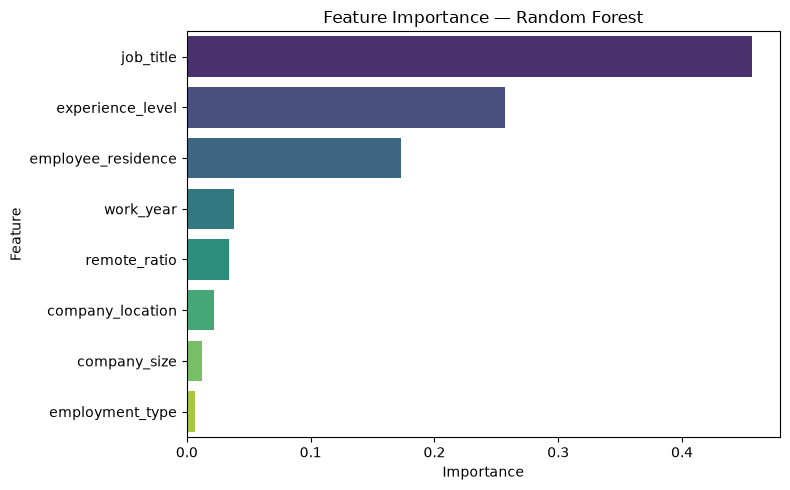

              Feature  Importance
3           job_title    0.456341
1    experience_level    0.257360
4  employee_residence    0.173100
0           work_year    0.038396
5        remote_ratio    0.033994
6    company_location    0.021979
7        company_size    0.012246
2     employment_type    0.006584


In [18]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

print(importance_df)

In [19]:
os.makedirs(MODEL_PATH, exist_ok=True)

joblib.dump(voting_model, MODEL_PATH + 'voting_model.pkl')
joblib.dump(rf, MODEL_PATH + 'random_forest.pkl')
joblib.dump(encoders, MODEL_PATH + 'encoders.pkl')
joblib.dump(X.columns.tolist(), MODEL_PATH + 'feature_columns.pkl')

print("✅ Saved to:", MODEL_PATH)
print(os.listdir(MODEL_PATH))

✅ Saved to: ../models/
['encoders.pkl', 'feature_columns.pkl', 'random_forest.pkl', 'voting_model.pkl']


In [20]:
# Fresh copy — redo cleaning
fresh = df.drop(['salary', 'salary_currency'], axis=1).copy()
fresh = fresh[(fresh['salary_in_usd'] >= 1000) & (fresh['salary_in_usd'] <= 500_000)]

# Group rare categories
def group_rare(series, min_count=100, other='Other'):
    counts = series.value_counts()
    return series.where(series.isin(counts[counts >= min_count].index), other)

fresh['job_title'] = group_rare(fresh['job_title'], 100)
fresh['employee_residence'] = group_rare(fresh['employee_residence'], 50)
fresh['company_location'] = group_rare(fresh['company_location'], 50)

print("✅ Cleaned:", fresh.shape)
print("Unique job titles:", fresh['job_title'].nunique())

# ===== CRITICAL: Split FIRST, then build the feature =====
train_df, test_df = train_test_split(fresh, test_size=0.2, random_state=42)

# Compute mean salary per job_title FROM TRAINING DATA ONLY
title_mean = train_df.groupby('job_title')['salary_in_usd'].mean()
global_mean = train_df['salary_in_usd'].mean()

# Apply to both (test uses train's mapping — no leakage)
for d in [train_df, test_df]:
    d['job_title_avg_salary'] = d['job_title'].map(title_mean).fillna(global_mean)

print("\n✅ Feature added (no leakage).")
print(train_df[['job_title', 'job_title_avg_salary', 'salary_in_usd']].head(3))
print("\nGlobal mean:", f"${global_mean:,.0f}")
print("Sample title means:")
print(title_mean.sort_values(ascending=False).head(10))

✅ Cleaned: (93392, 9)
Unique job titles: 65

✅ Feature added (no leakage).
                       job_title  job_title_avg_salary  salary_in_usd
16062  Machine Learning Engineer         195712.645956         195000
84406         Analytics Engineer         150882.526834         150000
76208  Machine Learning Engineer         195712.645956         168300

Global mean: $156,502
Sample title means:
job_title
Engineering Manager          253499.021053
Head of Data                 219880.120690
AI Architect                 207871.585938
Member of Technical Staff    200502.380952
Research Engineer            199671.580513
Machine Learning Engineer    195712.645956
Research Scientist           195118.316547
Solutions Architect          194070.640000
Product Manager              192480.616772
Architect                    191828.178947
Name: salary_in_usd, dtype: float64


In [23]:
cat_cols = ['experience_level', 'employment_type', 'job_title',
            'employee_residence', 'company_location', 'company_size']

encoders_v2 = {}
X2_train = train_df.drop('salary_in_usd', axis=1).copy()
X2_test  = test_df.drop('salary_in_usd', axis=1).copy()
y2_train = train_df['salary_in_usd'].copy()
y2_test  = test_df['salary_in_usd'].copy()

for col in cat_cols:
    le = LabelEncoder()
    le.fit(pd.concat([X2_train[col], X2_test[col]]).astype(str))
    X2_train[col] = le.transform(X2_train[col].astype(str))
    X2_test[col]  = le.transform(X2_test[col].astype(str))
    encoders_v2[col] = le

print("Features:", X2_train.columns.tolist())
print("Train:", X2_train.shape, "| Test:", X2_test.shape)

models_v2 = {
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=15),
    'Linear Regression': LinearRegression()
}

results_v2 = {}
print("\n" + "="*70)
for name, model in models_v2.items():
    model.fit(X2_train, y2_train)
    preds = model.predict(X2_test)
    r2 = r2_score(y2_test, preds)
    mae = mean_absolute_error(y2_test, preds)
    rmse = np.sqrt(mean_squared_error(y2_test, preds))
    results_v2[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name:20s} | MAE: ${mae:>10,.0f} | RMSE: ${rmse:>10,.0f} | R²: {r2:>7.4f}")

Features: ['work_year', 'experience_level', 'employment_type', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size', 'job_title_avg_salary']
Train: (74713, 9) | Test: (18679, 9)

Random Forest        | MAE: $    44,603 | RMSE: $    58,267 | R²:  0.3198
Gradient Boosting    | MAE: $    44,962 | RMSE: $    58,663 | R²:  0.3105
Decision Tree        | MAE: $    44,755 | RMSE: $    58,522 | R²:  0.3138
Linear Regression    | MAE: $    47,150 | RMSE: $    61,050 | R²:  0.2533


In [22]:
voting_v2 = VotingRegressor([
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)),
    ('dt', DecisionTreeRegressor(random_state=42, max_depth=15)),
])

voting_v2.fit(X2_train, y2_train)
preds = voting_v2.predict(X2_test)

mae = mean_absolute_error(y2_test, preds)
rmse = np.sqrt(mean_squared_error(y2_test, preds))
r2 = r2_score(y2_test, preds)

print(f"{'Voting Ensemble v2':20s} | MAE: ${mae:>10,.0f} | RMSE: ${rmse:>10,.0f} | R²: {r2:>7.4f}")

Voting Ensemble v2   | MAE: $    44,476 | RMSE: $    58,101 | R²:  0.3237


                Feature  Importance
8  job_title_avg_salary    0.547024
1      experience_level    0.161750
4    employee_residence    0.156945
0             work_year    0.034212
3             job_title    0.033913
5          remote_ratio    0.026282
6      company_location    0.024421
7          company_size    0.009192
2       employment_type    0.006262


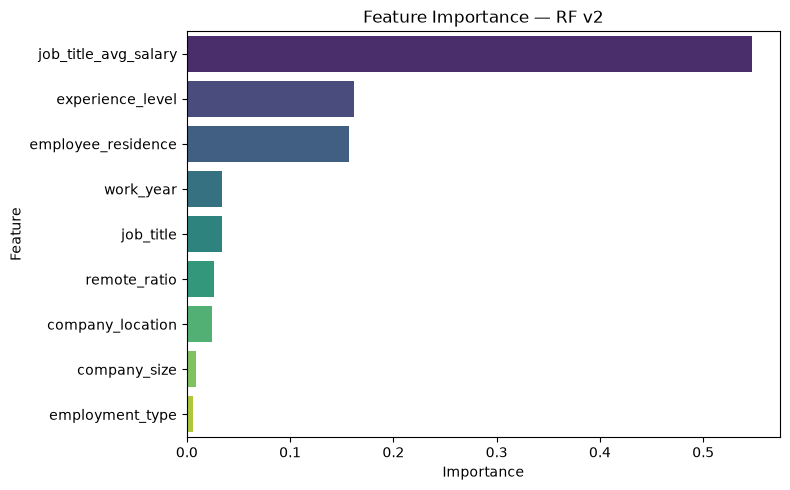

In [24]:
rf_v2 = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_v2.fit(X2_train, y2_train)

importance_v2 = pd.DataFrame({
    'Feature': X2_train.columns,
    'Importance': rf_v2.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_v2)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_v2, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — RF v2')
plt.tight_layout()
plt.show()

In [25]:
# Drop the raw high-cardinality categoricals and keep the engineered feature
X3_train = X2_train.drop(['job_title', 'employee_residence', 'company_location'], axis=1)
X3_test  = X2_test.drop(['job_title', 'employee_residence', 'company_location'], axis=1)

print("New feature set:", X3_train.columns.tolist())
print("Shape:", X3_train.shape)

models_v3 = {
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
}

print("\n" + "="*70)
for name, model in models_v3.items():
    model.fit(X3_train, y2_train)
    preds = model.predict(X3_test)
    r2 = r2_score(y2_test, preds)
    mae = mean_absolute_error(y2_test, preds)
    print(f"{name:20s} | MAE: ${mae:>10,.0f} | R²: {r2:>7.4f}")

New feature set: ['work_year', 'experience_level', 'employment_type', 'remote_ratio', 'company_size', 'job_title_avg_salary']
Shape: (74713, 6)

Random Forest        | MAE: $    46,612 | R²:  0.2700
Gradient Boosting    | MAE: $    46,833 | R²:  0.2645


In [26]:
# Log-transform target
y2_train_log = np.log1p(y2_train)
y2_test_log  = np.log1p(y2_test)

rf_log = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_log.fit(X2_train, y2_train_log)

# Predict → inverse transform back to dollars
preds_log = rf_log.predict(X2_test)
preds_dollars = np.expm1(preds_log)

r2_log = r2_score(y2_test, preds_dollars)
mae_log = mean_absolute_error(y2_test, preds_dollars)

print(f"{'RF + Log Target':20s} | MAE: ${mae_log:>10,.0f} | R²: {r2_log:>7.4f}")
print(f"Baseline (no log):     MAE: ${results_v2['Random Forest']['MAE']:>10,.0f} | R²: {results_v2['Random Forest']['R2']:>7.4f}")

RF + Log Target      | MAE: $    44,058 | R²:  0.3017
Baseline (no log):     MAE: $    44,603 | R²:  0.3198


In [27]:
# Interaction feature: senior + high-paying title = very high salary
for df_ in [X2_train, X2_test]:
    df_['exp_x_title'] = df_['experience_level'] * df_['job_title_avg_salary']
    df_['year_x_title'] = df_['work_year'] * df_['job_title_avg_salary']

print("Features now:", X2_train.columns.tolist())

rf_inter = RandomForestRegressor(n_estimators=300, max_depth=25, random_state=42, n_jobs=-1)
rf_inter.fit(X2_train, y2_train)
preds = rf_inter.predict(X2_test)

r2 = r2_score(y2_test, preds)
mae = mean_absolute_error(y2_test, preds)
print(f"\n{'RF + Interactions':20s} | MAE: ${mae:>10,.0f} | R²: {r2:>7.4f}")

Features now: ['work_year', 'experience_level', 'employment_type', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size', 'job_title_avg_salary', 'exp_x_title', 'year_x_title']

RF + Interactions    | MAE: $    44,607 | R²:  0.3196


In [29]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("="*70)
for name, model in [('XGBoost', xgb), ('LightGBM', lgbm)]:
    model.fit(X2_train, y2_train)
    preds = model.predict(X2_test)
    r2 = r2_score(y2_test, preds)
    mae = mean_absolute_error(y2_test, preds)
    print(f"{name:20s} | MAE: ${mae:>10,.0f} | R²: {r2:>7.4f}")

XGBoost              | MAE: $    44,502 | R²:  0.3228
LightGBM             | MAE: $    44,480 | R²:  0.3232


In [30]:
voting_final = VotingRegressor([
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=25, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=8,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, n_jobs=-1, verbosity=0)),
    ('lgbm', LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=8,
                            random_state=42, n_jobs=-1, verbose=-1)),
])

voting_final.fit(X2_train, y2_train)
preds = voting_final.predict(X2_test)

mae = mean_absolute_error(y2_test, preds)
rmse = np.sqrt(mean_squared_error(y2_test, preds))
r2 = r2_score(y2_test, preds)

print(f"\n{'🏆 Voting Ensemble':20s} | MAE: ${mae:>10,.0f} | RMSE: ${rmse:>10,.0f} | R²: {r2:>7.4f}")


🏆 Voting Ensemble    | MAE: $    44,445 | RMSE: $    58,078 | R²:  0.3242


In [31]:
import os
os.makedirs('../models', exist_ok=True)

# Save the winning ensemble + ALL preprocessing artifacts
joblib.dump(voting_final, '../models/salary_model.pkl')
joblib.dump(encoders_v2, '../models/encoders.pkl')
joblib.dump(title_mean, '../models/title_mean.pkl')      # for job_title_avg_salary
joblib.dump(global_mean, '../models/global_mean.pkl')
joblib.dump(X2_train.columns.tolist(), '../models/feature_columns.pkl')

print("✅ Saved to ../models/:")
for f in os.listdir('../models'):
    size = os.path.getsize(f'../models/{f}') / 1024
    print(f"   {f}  ({size:.1f} KB)")

✅ Saved to ../models/:
   encoders.pkl  (3.1 KB)
   feature_columns.pkl  (0.2 KB)
   global_mean.pkl  (0.1 KB)
   random_forest.pkl  (37250.4 KB)
   salary_model.pkl  (117463.7 KB)
   title_mean.pkl  (5.2 KB)
   voting_model.pkl  (37391.3 KB)


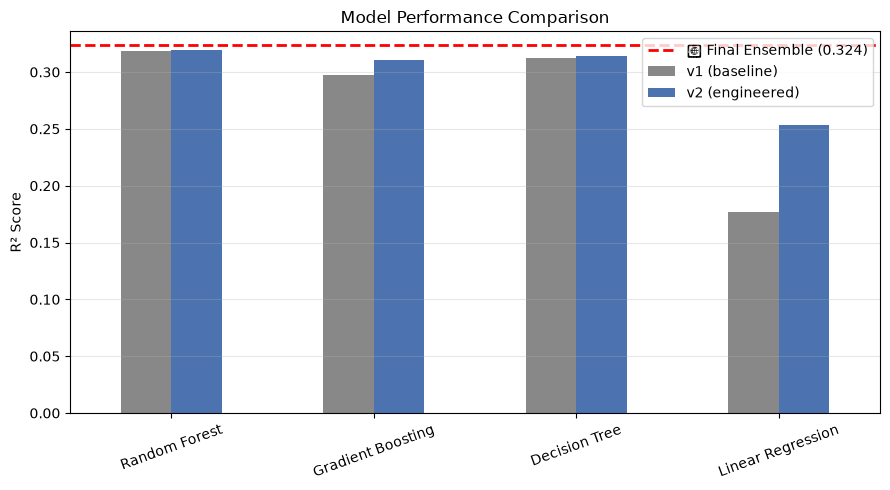

✅ Saved chart to ../models/comparison.png


In [32]:
comparison = pd.DataFrame({
    'v1 (baseline)': [0.3187, 0.2973, 0.3127, 0.1765],
    'v2 (engineered)': [0.3198, 0.3105, 0.3138, 0.2533],
}, index=['Random Forest', 'Gradient Boosting', 'Decision Tree', 'Linear Regression'])

fig, ax = plt.subplots(figsize=(9, 5))
comparison.plot(kind='bar', ax=ax, color=['#888', '#4C72B0'])
ax.axhline(0.3242, color='red', linestyle='--', lw=2, label='🏆 Final Ensemble (0.324)')
ax.set_ylabel('R² Score')
ax.set_title('Model Performance Comparison')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../models/comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Saved chart to ../models/comparison.png")

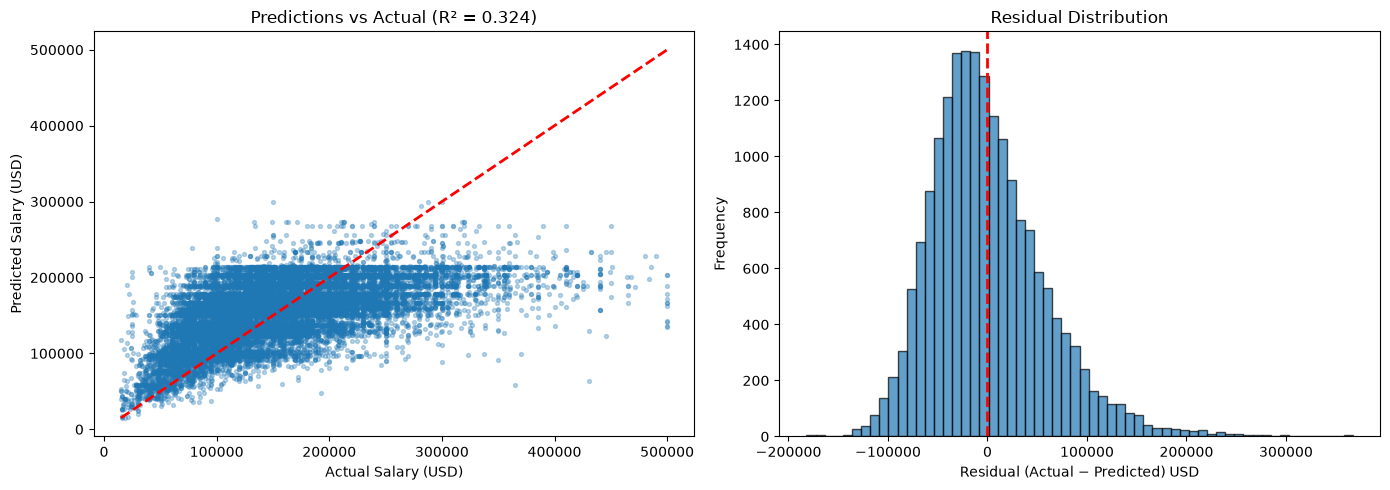

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predictions vs actual
axes[0].scatter(y2_test, voting_final.predict(X2_test), alpha=0.3, s=8)
axes[0].plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Salary (USD)')
axes[0].set_ylabel('Predicted Salary (USD)')
axes[0].set_title(f'Predictions vs Actual (R² = {r2_score(y2_test, voting_final.predict(X2_test)):.3f})')

# Residuals
residuals = y2_test - voting_final.predict(X2_test)
axes[1].hist(residuals, bins=60, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (Actual − Predicted) USD')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('../models/residuals.png', dpi=100, bbox_inches='tight')
plt.show()

In [34]:
import os

# Keep only what's needed for inference
KEEP = ['salary_model.pkl', 'encoders.pkl', 'title_mean.pkl', 
        'global_mean.pkl', 'feature_columns.pkl',
        'comparison.png', 'residuals.png']

for f in os.listdir('../models'):
    if f not in KEEP:
        os.remove(f'../models/{f}')
        print(f"🗑️  Removed {f}")

print("\n✅ Final models/ contents:")
for f in sorted(os.listdir('../models')):
    size = os.path.getsize(f'../models/{f}') / 1024 / 1024
    print(f"   {f:25s} ({size:.1f} MB)")

🗑️  Removed random_forest.pkl
🗑️  Removed voting_model.pkl

✅ Final models/ contents:
   comparison.png            (0.0 MB)
   encoders.pkl              (0.0 MB)
   feature_columns.pkl       (0.0 MB)
   global_mean.pkl           (0.0 MB)
   residuals.png             (0.1 MB)
   salary_model.pkl          (114.7 MB)
   title_mean.pkl            (0.0 MB)


In [35]:
import joblib
import pandas as pd

# Reload
loaded_model = joblib.load('../models/salary_model.pkl')
loaded_encoders = joblib.load('../models/encoders.pkl')
loaded_title_mean = joblib.load('../models/title_mean.pkl')
loaded_global_mean = joblib.load('../models/global_mean.pkl')
loaded_cols = joblib.load('../models/feature_columns.pkl')

print("✅ Model loaded")
print("Expected columns:", loaded_cols)

# Quick test prediction
sample = X2_test.iloc[[0]]
print("\nSample input:")
print(sample)
print(f"\nActual:    ${y2_test.iloc[0]:,.0f}")
print(f"Predicted: ${loaded_model.predict(sample)[0]:,.0f}")

✅ Model loaded
Expected columns: ['work_year', 'experience_level', 'employment_type', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size', 'job_title_avg_salary', 'exp_x_title', 'year_x_title']

Sample input:
       work_year  experience_level  employment_type  job_title  \
34350       2024                 0                2          3   

       employee_residence  remote_ratio  company_location  company_size  \
34350                  18           100                18             1   

       job_title_avg_salary  exp_x_title  year_x_title  
34350          111688.15867          0.0  2.260568e+08  

Actual:    $152,000
Predicted: $100,434


In [36]:
import joblib
import os

# Reload and re-save compressed
model = joblib.load('../models/salary_model.pkl')

# compress=3 uses zlib — 5-10x smaller, negligible load-time cost
joblib.dump(model, '../models/salary_model.pkl', compress=3)

size_mb = os.path.getsize('../models/salary_model.pkl') / 1024 / 1024
print(f"✅ Re-saved with compression: {size_mb:.1f} MB (was 114.7 MB)")

✅ Re-saved with compression: 32.8 MB (was 114.7 MB)


In [37]:
import pandas as pd
import joblib

# Reload (compressed)
model = joblib.load('../models/salary_model.pkl')
encoders = joblib.load('../models/encoders.pkl')
title_mean = joblib.load('../models/title_mean.pkl')
global_mean = joblib.load('../models/global_mean.pkl')

# Pick a high-paid example from test set to verify
X2_test_reset = X2_test.reset_index(drop=True)
y2_test_reset = y2_test.reset_index(drop=True)

# Compare predictions across the whole test set
all_preds = model.predict(X2_test)

print(f"Actual mean:    ${y2_test.mean():>10,.0f}")
print(f"Predicted mean: ${all_preds.mean():>10,.0f}")
print(f"Actual std:     ${y2_test.std():>10,.0f}")
print(f"Predicted std:  ${all_preds.std():>10,.0f}")

# Show error distribution
errors = y2_test - all_preds
print(f"\nMedian error:   ${errors.median():>10,.0f}")
print(f"Mean error:     ${errors.mean():>10,.0f}")
print(f"Within $50K:    {(abs(errors) < 50000).mean()*100:.1f}%")
print(f"Within $25K:    {(abs(errors) < 25000).mean()*100:.1f}%")

Actual mean:    $   156,577
Predicted mean: $   156,390
Actual std:     $    70,651
Predicted std:  $    40,586

Median error:   $    -7,839
Mean error:     $       187
Within $50K:    64.8%
Within $25K:    35.4%
